In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform
from toy_helpers import M_HF, M_LF, generate_noisy_data, X, Y, resolution

In [18]:
THETA = np.array([[1/20,1]])
# Evaluate the function over the grid
Z_HF = M_HF(THETA)
# Evaluate the function over the grid
Z_LF = M_LF(THETA)
noise_st_dev = 2000
meas_data = generate_noisy_data(THETA, noise_st_dev)

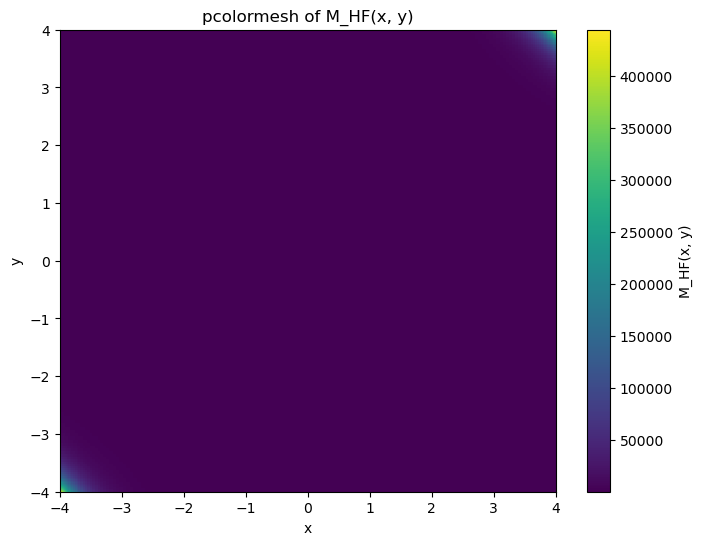

In [3]:
# Create the plot
plt.figure(figsize=(8, 6))
# shading='auto' is recommended for pcolormesh
mesh = plt.pcolormesh(X, Y, Z_HF[0].reshape(resolution,resolution), shading='auto', cmap='viridis') 

# Add a colorbar and labels
plt.colorbar(mesh, label='M_HF(x, y)')
plt.title('pcolormesh of M_HF(x, y)')
plt.xlabel('x')
plt.ylabel('y')

# Display the plot
plt.show()

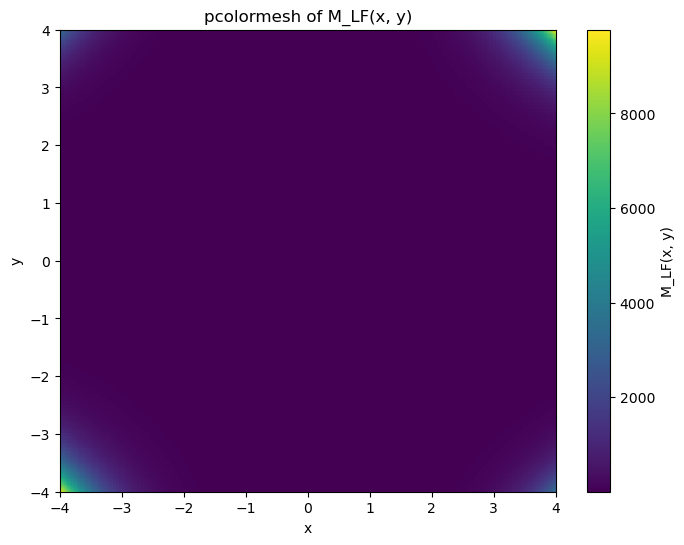

In [6]:
# Create the plot
plt.figure(figsize=(8, 6))
# shading='auto' is recommended for pcolormesh
mesh = plt.pcolormesh(X, Y, Z_LF[0].reshape(resolution,resolution), shading='auto', cmap='viridis')

# Add a colorbar and labels
plt.colorbar(mesh, label='M_LF(x, y)')
plt.title('pcolormesh of M_LF(x, y)')
plt.xlabel('x')
plt.ylabel('y')

# Display the plot
plt.show()

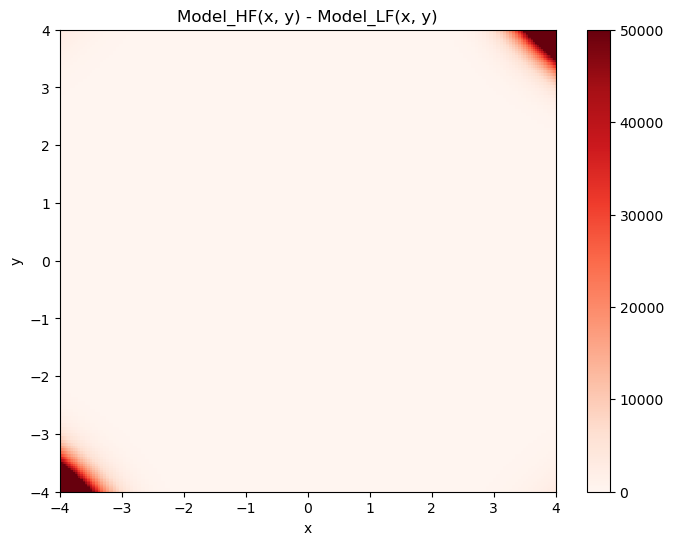

In [9]:
# Create the plot
plt.figure(figsize=(8, 6))
# shading='auto' is recommended for pcolormesh
mesh = plt.pcolormesh(X, Y, np.abs(Z_HF[0].reshape(resolution,resolution) - Z_LF[0].reshape(resolution,resolution)), shading='auto', cmap='Reds', vmax = 50_000)

# Add a colorbar and labels
plt.colorbar(mesh)
plt.title('Model_HF(x, y) - Model_LF(x, y)')
plt.xlabel('x')
plt.ylabel('y')

# Display the plot
plt.show()

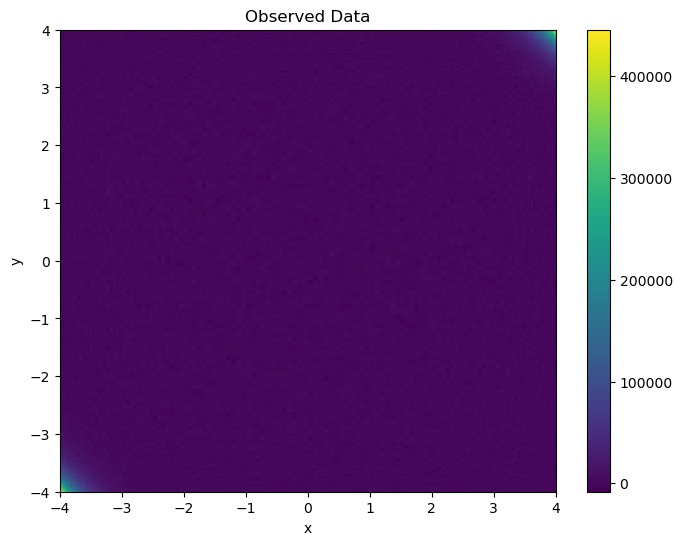

In [19]:
# Create the plot
plt.figure(figsize=(8, 6))
# shading='auto' is recommended for pcolormesh
mesh = plt.pcolormesh(X, Y, meas_data.reshape(resolution,resolution), shading='auto', cmap='viridis')

# Add a colorbar and labels
plt.colorbar(mesh)
plt.title('Observed Data')
plt.xlabel('x')
plt.ylabel('y')

# Display the plot
plt.show()

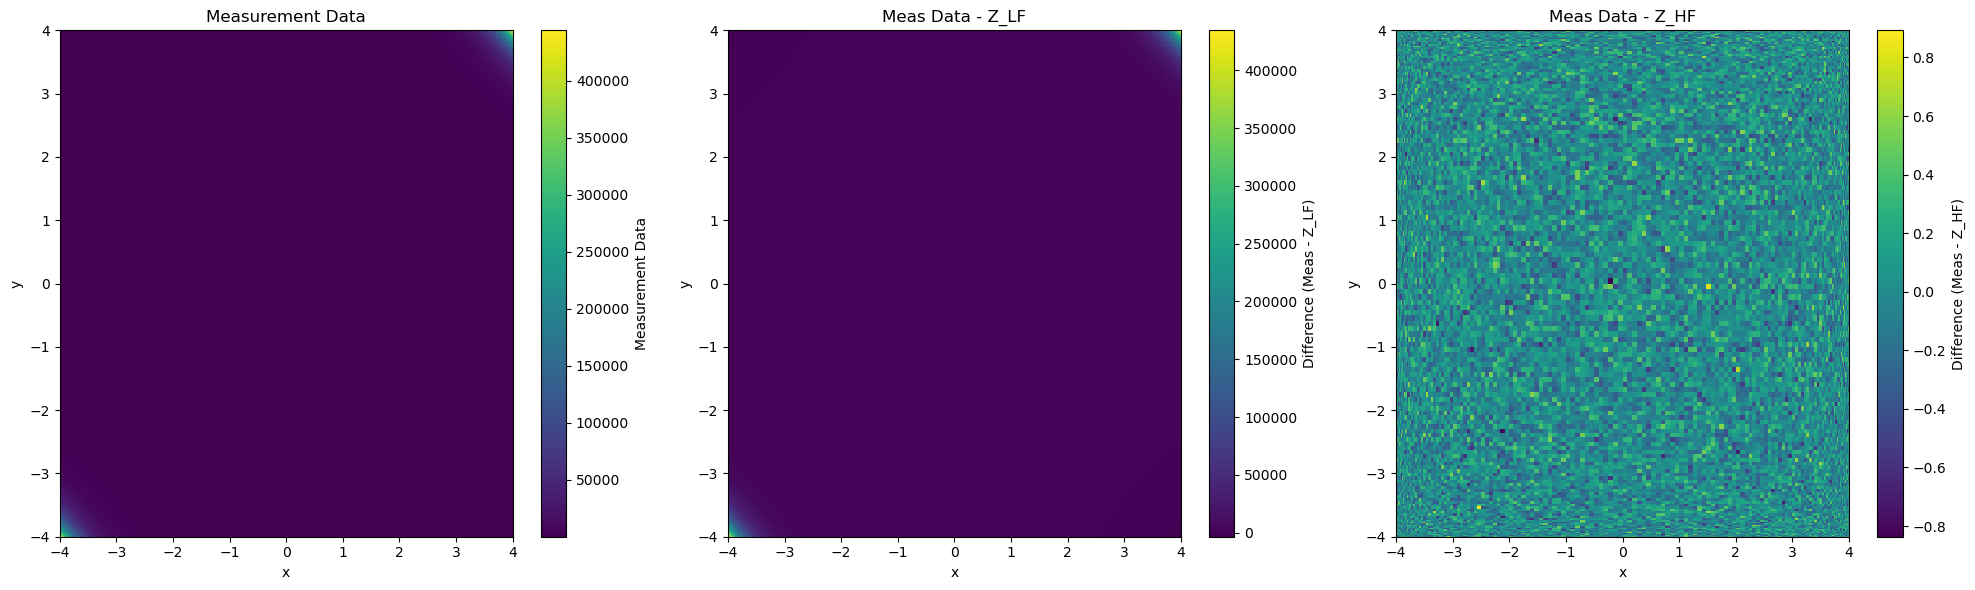

In [14]:
# Create a 1 by 3 subplot figure
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: Measurement Data ---
mesh1 = axes[0].pcolormesh(X, Y, meas_data.reshape(resolution,resolution), shading='auto', cmap='viridis')
fig.colorbar(mesh1, ax=axes[0], label='Measurement Data')
axes[0].set_title('Measurement Data')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

# --- Plot 2: Measurement Data vs Z_LF (Low-Fidelity) ---
# Note: You can change 'viridis' to 'coolwarm' for a better visual of positive/negative residuals
diff_LF = (meas_data.reshape(resolution,resolution) - Z_LF[0].reshape(resolution,resolution))
mesh2 = axes[1].pcolormesh(X, Y, diff_LF, shading='auto', cmap='viridis')
fig.colorbar(mesh2, ax=axes[1], label='Difference (Meas - Z_LF)')
axes[1].set_title('Meas Data - Z_LF')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

# --- Plot 3: Measurement Data vs Z_HF (High-Fidelity) ---
diff_HF = (meas_data.reshape(resolution,resolution) - Z_HF[0].reshape(resolution,resolution))
mesh3 = axes[2].pcolormesh(X, Y, diff_HF, shading='auto', cmap='viridis')
fig.colorbar(mesh3, ax=axes[2], label='Difference (Meas - Z_HF)')
axes[2].set_title('Meas Data - Z_HF')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')

# Adjust layout so subplots don't overlap
plt.tight_layout()

# Display the plot
plt.show()